<a href="https://colab.research.google.com/github/raisharad/GenerativeAIandAgenticAI/blob/main/RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retrieval Augmented Generation (Sparse retrieval)

Contents:

0. LLM Loading and utility function definition
1. Indexing
2. Retrieval
3. Augmentation
4. Generation

## Model Loading and Utility functions

Load the model weights using the transformers library, and define utility functions

In [1]:
import torch
from transformers import pipeline

MODEL_ID = "unsloth/Llama-3.2-3B-Instruct"

pipe = pipeline(
    "text-generation",
    model=MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="cuda",
)

print("Loaded", MODEL_ID, "on", pipe.model.device)

config.json:   0%|          | 0.00/890 [00:00<?, ?B/s]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json:   0%|          | 0.00/20.9k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.2MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

Loaded unsloth/Llama-3.2-3B-Instruct on cuda:0


In [3]:
def make_message(system_content, user_content):
    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content},
    ]

def fetch_response(response):
    return response[0]["generated_text"][-1]["content"]

## The RAG flow

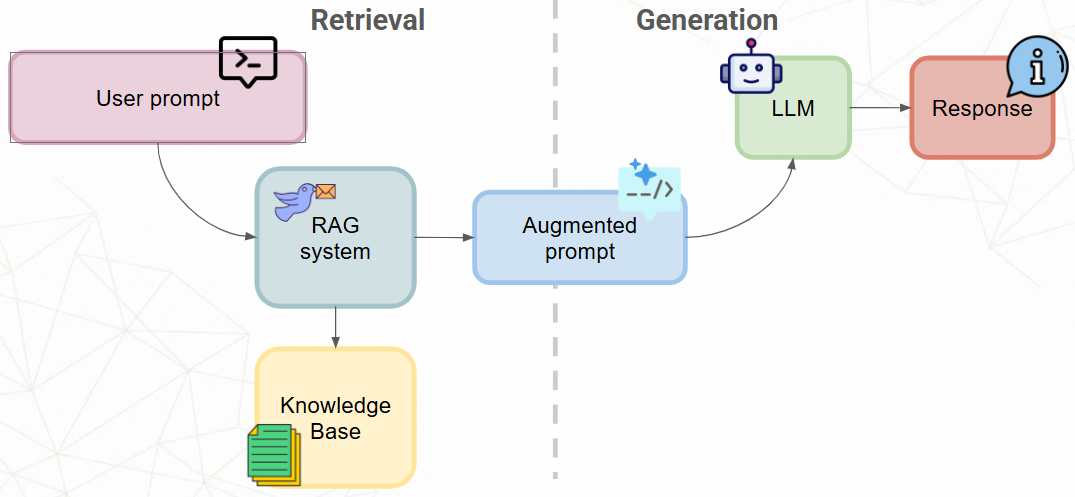

## Loading the required libraries


Fetching data from the internet: [feedparser](https://github.com/kurtmckee/feedparser)\
Indexing: [pyterrier](https://pyterrier.readthedocs.io/en/latest/)\
Retrieval: BM-25

In [4]:
!pip install python-terrier feedparser

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.1/223.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 947.8/947.8 kB 52.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 94.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.8/304.8 kB 30.7 MB/s eta 0:00:00


In [5]:
# import the necessary libraries like feedparser, pandas, and pyterrier
# initialize pyterrier
import feedparser
import pandas as pd
import pyterrier as pt
if not pt.started():
    pt.init()

/tmp/ipykernel_943/2797764700.py:6: DeprecationWarning: Call to deprecated function (or staticmethod) started. (use pt.java.started() instead) -- Deprecated since version 0.11.0.
  if not pt.started():


terrier-assemblies 5.11 jar-with-dependencies not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-assemblies/5.11/terrier-assemblies-5.11-jar-with-dependenci…

Done
terrier-python-helper 0.0.8 jar not found, downloading to /root/.pyterrier...


https://repo1.maven.org/maven2/org/terrier/terrier-python-helper/0.0.8/terrier-python-helper-0.0.8.jar:   0%| …

Done


Java started and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.java.24, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]
/tmp/ipykernel_943/2797764700.py:7: DeprecationWarning: Call to deprecated method pt.init(). Deprecated since version 0.11.0.
java is now started automatically with default settings. To force initialisation early, run:
pt.java.init() # optional, forces java initialisation
  pt.init()


## Failure case without RAG

We observe the response of the trained model with no external source of information

In [6]:
system_prompt = "You are a helpful financial assistant."

query = "What specific news events or reports are driving Tesla's (TSLA) stock price this week?"

In [8]:

# Format the message_without_rag using your helper function
message_without_rag = make_message(system_prompt, query)
response_without_rag = pipe(message_without_rag, max_new_tokens= 300, do_sample=False)
without_rag_answer = fetch_response (response_without_rag)


[transformers] Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [9]:
# Generate response_without_rag using pipe
print(without_rag_answer)

I'd be happy to provide you with the latest news and reports that may be driving Tesla's (TSLA) stock price. However, please note that my knowledge cutoff is December 2023, and I may not have real-time information.

That being said, here are some recent news events and reports that may have impacted Tesla's stock price:

1. **Elon Musk's Twitter Posts**: Elon Musk's recent tweets about Tesla's production and delivery numbers, as well as his comments on the company's financials, may have caused volatility in the stock price.
2. **Tesla's Q4 2023 Earnings Report**: Tesla released its Q4 2023 earnings report, which showed strong revenue growth and improved profitability. However, the report also highlighted challenges in meeting production targets and increasing deliveries.
3. **Cybertruck Production Issues**: There have been reports of production issues with Tesla's Cybertruck, which may have impacted the company's ability to meet delivery targets and increase sales.
4. **Competition fro

In [ ]:
# Extract without_rag_answer using your helper function


## Fetching live data

We will chose the Live Yahoo Finance RSS Feed for Tesla (TSLA) for this demonstration.The website contains updated collection of tesla related news article.

https://feeds.finance.yahoo.com/rss/2.0/headline?s=TSLA&region=US&lang=en-US

In [11]:
# create the feed using the parse method
rss_url='https://feeds.finance.yahoo.com/rss/2.0/headline?s=TSLA&region=US&lang=en-US'
feed = feedparser.parse(rss_url)
display(feed)

{'bozo': False,
 'entries': [{'summary': 'Intel (NasdaqGS: INTC) announces a joint venture with SpaceX and Tesla to build a semiconductor fabrication facility in Texas as part of the Terafab project. The Terafab facility is intended to support chips for next generation robotics and autonomous vehicle platforms used by SpaceX and Tesla. The partnership highlights efforts by the companies to tighten control over chip supply for AI hardware and advanced manufacturing in North America. The announcement positions Intel as a key foundry...',
   'summary_detail': {'type': 'text/html',
    'language': None,
    'base': 'https://feeds.finance.yahoo.com/rss/2.0/headline?s=TSLA&region=US&lang=en-US',
    'value': 'Intel (NasdaqGS: INTC) announces a joint venture with SpaceX and Tesla to build a semiconductor fabrication facility in Texas as part of the Terafab project. The Terafab facility is intended to support chips for next generation robotics and autonomous vehicle platforms used by SpaceX an

In [14]:
# Build our docs_df database
feed.keys()
len(feed.entries)

20

In [17]:
# Convert to DataFrame
feed.entries[0]
doc = []
for i, entry in enumerate(feed.entries):
    text= f"{entry.title}.{entry.summary}"
    doc.append({"docno": i, "text": text})
docs_df = pd.DataFrame(doc)
docs_df.head()
display(docs_df)

,docno,text
0,0,What Does Intel (INTC) Gain From Its Texas Chi...
1,1,SpaceX and Tesla choose Texas for AI chip manu...
2,2,"Stock Market Today, Aug. 7: Space Exploration ..."
3,3,"Gary Black Says Uber, Not Tesla or Waymo, Has ..."
4,4,Tesla Stock Rises to End Good Week. Thank the ...
5,5,2 Reasons Tesla Could Monopolize the U.S. Robo...
6,6,Tesla Stock Jumps Nearly 4% as $16.8 Billion T...
7,7,Tesla Jumps as Rate Fears Ease.Shares rose as ...
8,8,SpaceX’s Texas Terafab Could Become World’s La...
9,9,"Musk's SpaceX, Tesla to build $16.8B Terafab c..."


## Indexing

We use pyterrier to index the fetched data.


Folder: "./tesla_news_index"

In [19]:
# Create an indexer using IterDictIndexer class
indexer = pt.IterDictIndexer("./tesla_news_index", overwrite=True)


In [23]:
docs_df['docno'] = docs_df['docno'].astype(str)
index_ref = indexer.index(docs_df.to_dict(orient="records"))

## Retrieval

We use BM25 to rank the chunks and retrieve the top-3 relevant chunks

In [24]:
# Create the BM25 Retriever using BatchRetrieve
bm25 = pt.BatchRetrieve(index_ref, wmodel="BM25")

/tmp/ipykernel_943/2573002557.py:2: DeprecationWarning: Call to deprecated class BatchRetrieve. (use pt.terrier.Retriever() instead) -- Deprecated since version 0.11.0.
  bm25 = pt.BatchRetrieve(index_ref, wmodel="BM25")


In [26]:
# Search the PyTerrier index using search method

search_results = bm25.search(query)
display(search_results)

,qid,query,docid,docno,rank,score
0,1,What specific news events or reports are drivi...,14,14,0,7.922732e+00
1,1,What specific news events or reports are drivi...,4,4,1,5.049490e+00
2,1,What specific news events or reports are drivi...,18,18,2,4.113043e+00
3,1,What specific news events or reports are drivi...,16,16,3,2.759598e+00
4,1,What specific news events or reports are drivi...,19,19,4,1.529491e+00
5,1,What specific news events or reports are drivi...,15,15,5,1.322645e+00
6,1,What specific news events or reports are drivi...,17,17,6,7.592348e-01
7,1,What specific news events or reports are drivi...,12,12,7,6.336702e-01
8,1,What specific news events or reports are drivi...,2,2,8,6.017609e-01
9,1,What specific news events or reports are drivi...,9,9,9,4.266731e-01


In [28]:
# Merge into top_docs our docs_df and search_results to see the full content
top_docs = search_results.merge(docs_df, on="docno").head(3)
display(top_docs)

,qid,query,docid,docno,rank,score,text
0,1,What specific news events or reports are drivi...,14,14,0,7.922732,Stock Market Forecast: Weak Jobs Report Trigge...
1,1,What specific news events or reports are drivi...,4,4,1,5.049490,Tesla Stock Rises to End Good Week. Thank the ...
2,1,What specific news events or reports are drivi...,18,18,2,4.113043,Electric Vehicles Today - LiDAR Market Growth ...


In [30]:
# Combine the top 3 articles into a single block of context
context = "\n\n ".join(top_docs["text"])
display(context)

'Stock Market Forecast: Weak Jobs Report Triggers Premarket Tech Rally.The major stocks in this report all look likely to jump at the open, as Wall Street celebrates job losses in a “bad news is good news” move.\n\n Tesla Stock Rises to End Good Week. Thank the Usual Suspects..FEATURE   Tesla stock rose Friday, helping shares snap a three-week losing streak. Retail traders, as usual, are helping. Shares of the EV maker gained 2.8% to $328.58 on Friday, while the and rose 0.\n\n Electric Vehicles Today - LiDAR Market Growth Driven By Automated Driving Systems.The global automotive LiDAR market is projected to experience significant growth, reaching $11.26 billion by 2033, driven by the adoption of advanced Level 2+ and Level 3 automated driving systems in electric vehicles. This growth is supported by the push towards integrating solid-state LiDAR and semiconductor technologies to enhance intelligent vehicle production. The Asia-Pacific region leads in LiDAR adoption, aided by strong in

In [31]:
#print context
print(context)

Stock Market Forecast: Weak Jobs Report Triggers Premarket Tech Rally.The major stocks in this report all look likely to jump at the open, as Wall Street celebrates job losses in a “bad news is good news” move.

 Tesla Stock Rises to End Good Week. Thank the Usual Suspects..FEATURE   Tesla stock rose Friday, helping shares snap a three-week losing streak. Retail traders, as usual, are helping. Shares of the EV maker gained 2.8% to $328.58 on Friday, while the and rose 0.

 Electric Vehicles Today - LiDAR Market Growth Driven By Automated Driving Systems.The global automotive LiDAR market is projected to experience significant growth, reaching $11.26 billion by 2033, driven by the adoption of advanced Level 2+ and Level 3 automated driving systems in electric vehicles. This growth is supported by the push towards integrating solid-state LiDAR and semiconductor technologies to enhance intelligent vehicle production. The Asia-Pacific region leads in LiDAR adoption, aided by strong intelli

## Augmentation

The prompt is augmented with the context of the retrieved chunks

In [36]:
# Define a strict RAG system prompt
rag_system_prompt = """You are a highly accurate financial analyst.
You will be provided with live context from a news database.
Answer the user's question ONLY using the provided context."""



In [33]:
# Combine Context and Query for the user prompt
user_prompt_with_context = f"Context: \n{context}\n\nQuestion: {query}"
print(user_prompt_with_context)

Context: 
Stock Market Forecast: Weak Jobs Report Triggers Premarket Tech Rally.The major stocks in this report all look likely to jump at the open, as Wall Street celebrates job losses in a “bad news is good news” move.

 Tesla Stock Rises to End Good Week. Thank the Usual Suspects..FEATURE   Tesla stock rose Friday, helping shares snap a three-week losing streak. Retail traders, as usual, are helping. Shares of the EV maker gained 2.8% to $328.58 on Friday, while the and rose 0.

 Electric Vehicles Today - LiDAR Market Growth Driven By Automated Driving Systems.The global automotive LiDAR market is projected to experience significant growth, reaching $11.26 billion by 2033, driven by the adoption of advanced Level 2+ and Level 3 automated driving systems in electric vehicles. This growth is supported by the push towards integrating solid-state LiDAR and semiconductor technologies to enhance intelligent vehicle production. The Asia-Pacific region leads in LiDAR adoption, aided by stro

## Generation

The LLM is prompted with the augmented query

In [39]:
# Format the message_with_rag using your helper function
message_with_rag = make_message(rag_system_prompt, user_prompt_with_context)


In [41]:
# Generate response_with_rag
response_with_rag = pipe(message_with_rag, max_new_tokens= 300, do_sample=False)
with_rag_answer = fetch_response (response_with_rag)

[transformers] Both `max_new_tokens` (=300) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [42]:
# Extract with_rag_answer using your helper function
print(with_rag_answer)

According to the provided context, Tesla's (TSLA) stock price is rising due to a "bad news is good news" move in the stock market, triggered by a weak jobs report. Additionally, the context mentions that Tesla's stock rose on Friday, helping shares snap a three-week losing streak, but it does not specifically mention any other news events or reports driving the stock price this week.


## Comparison

We compare the LLM generated answer with that of a RAG implementation on the same LLM

In [43]:
print("="*80)
print(f"QUESTION: {query}")
print("="*80)

print("\nWITHOUT RAG (Model refuses or hallucinates):")
print(without_rag_answer)

print("\nWITH RAG (Grounded in Live Database):")
print(with_rag_answer)



QUESTION: What specific news events or reports are driving Tesla's (TSLA) stock price this week?

WITHOUT RAG (Model refuses or hallucinates):
I'd be happy to provide you with the latest news and reports that may be driving Tesla's (TSLA) stock price. However, please note that my knowledge cutoff is December 2023, and I may not have real-time information.

That being said, here are some recent news events and reports that may have impacted Tesla's stock price:

1. **Elon Musk's Twitter Posts**: Elon Musk's recent tweets about Tesla's production and delivery numbers, as well as his comments on the company's financials, may have caused volatility in the stock price.
2. **Tesla's Q4 2023 Earnings Report**: Tesla released its Q4 2023 earnings report, which showed strong revenue growth and improved profitability. However, the report also highlighted challenges in meeting production targets and increasing deliveries.
3. **Cybertruck Production Issues**: There have been reports of production 

In [44]:
print("\n" + "="*80)
print("EVIDENCE CITED (BM25 Top 3 Retrieved Articles):")
print("="*80)
for i, row in top_docs.iterrows():
    print(f"Rank {i+1} (Score: {row['score']:.2f})")
    print(f"Text: {row['text']}")
    print("-" * 50)


EVIDENCE CITED (BM25 Top 3 Retrieved Articles):
Rank 1 (Score: 7.92)
Text: Stock Market Forecast: Weak Jobs Report Triggers Premarket Tech Rally.The major stocks in this report all look likely to jump at the open, as Wall Street celebrates job losses in a “bad news is good news” move.
--------------------------------------------------
Rank 2 (Score: 5.05)
Text: Tesla Stock Rises to End Good Week. Thank the Usual Suspects..FEATURE   Tesla stock rose Friday, helping shares snap a three-week losing streak. Retail traders, as usual, are helping. Shares of the EV maker gained 2.8% to $328.58 on Friday, while the and rose 0.
--------------------------------------------------
Rank 3 (Score: 4.11)
Text: Electric Vehicles Today - LiDAR Market Growth Driven By Automated Driving Systems.The global automotive LiDAR market is projected to experience significant growth, reaching $11.26 billion by 2033, driven by the adoption of advanced Level 2+ and Level 3 automated driving systems in electric veh

## Conclusion

The LLM can answer questions beyond its knowledge by utilizing live data and RAG pipeline.